# Inadimplência no Pix Parcelado — 3. Modelo simples de IA

Pra fechar o estudo, tentei montar um modelo básico de regressão logística (o
mais simples e mais usado em crédito) pra ver se dá pra prever, com as
informações que tenho, quem tem mais chance de atrasar. Não usei nada muito
avançado de propósito — a ideia aqui é mostrar que entendo a lógica de montar e
avaliar um modelo, não ficar caçando o modelo mais complexo possível.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/pix_parcelado.csv")
df.head()


,cliente_id,idade,renda_estimada,valor_compra,qtd_parcelas,ja_usou_pix_parcelado_antes,score_credito,inadimplente,estrategia_lembrete,recuperou
0,CLI1000,22,2369.71,1814.17,4,1,834,0,NaN,0
1,CLI1001,43,1154.48,2600.64,4,0,802,0,NaN,0
2,CLI1002,21,2428.98,2223.55,9,0,629,0,NaN,0
3,CLI1003,37,2568.09,1837.05,9,0,516,1,Lembrete com opção de renegociar,0
4,CLI1004,41,5432.11,1546.46,9,0,506,0,NaN,0


## Preparando os dados

Só uso informação que eu teria **antes** de saber se o cliente vai atrasar ou
não (não faz sentido usar coisa como "recuperou", que só existe depois que a
pessoa já atrasou — isso seria trapaça/vazamento de dado).


In [2]:
features = ["idade", "renda_estimada", "valor_compra", "qtd_parcelas",
            "ja_usou_pix_parcelado_antes", "score_credito"]

X = df[features]
y = df["inadimplente"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                      random_state=7, stratify=y)

print(f"treino: {len(X_train)} | teste: {len(X_test)}")
print(f"taxa inadimplência treino: {y_train.mean():.1%} | teste: {y_test.mean():.1%}")


treino: 2250 | teste: 750
taxa inadimplência treino: 28.1% | teste: 28.1%


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo = LogisticRegression(class_weight="balanced")
modelo.fit(X_train_scaled, y_train)

proba = modelo.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, proba)
print(f"AUC do modelo: {auc:.3f}")


AUC do modelo: 0.777


## Curva ROC

Uma forma visual de ver o quão bom o modelo é pra separar quem paga de quem
atrasa. Quanto mais a curva "sobe" longe da linha pontilhada (que representa um
modelo aleatório), melhor.


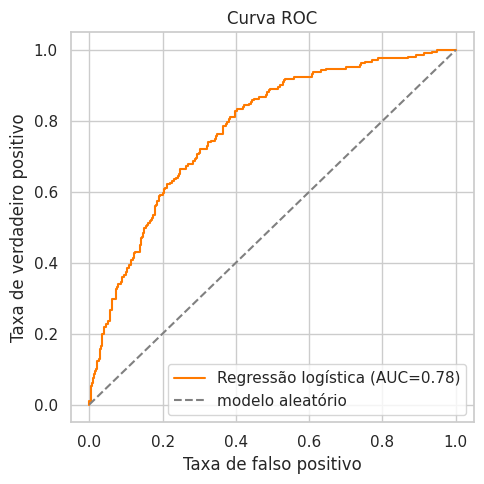

In [4]:
fpr, tpr, _ = roc_curve(y_test, proba)

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(fpr, tpr, label=f"Regressão logística (AUC={auc:.2f})", color="#FF7A00")
ax.plot([0,1],[0,1], linestyle="--", color="gray", label="modelo aleatório")
ax.set_xlabel("Taxa de falso positivo")
ax.set_ylabel("Taxa de verdadeiro positivo")
ax.set_title("Curva ROC")
ax.legend()
plt.tight_layout()
plt.savefig("../images/curva_roc.png", dpi=120)
plt.show()


              precision    recall  f1-score   support

       Pagou       0.87      0.65      0.75       539
     Atrasou       0.46      0.76      0.57       211

    accuracy                           0.68       750
   macro avg       0.67      0.70      0.66       750
weighted avg       0.76      0.68      0.70       750



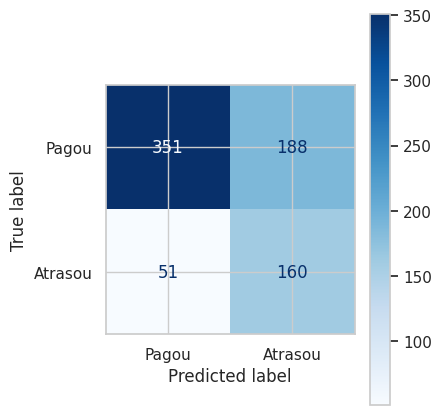

In [5]:
pred = modelo.predict(X_test_scaled)
print(classification_report(y_test, pred, target_names=["Pagou", "Atrasou"]))

fig, ax = plt.subplots(figsize=(4.5,4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Pagou","Atrasou"],
                                         cmap="Blues", ax=ax)
plt.tight_layout()
plt.savefig("../images/matriz_confusao.png", dpi=120)
plt.show()


## Quais variáveis pesaram mais

Olhando o coeficiente de cada variável no modelo, dá pra ter uma ideia de quais
delas mais "empurram" a previsão pra inadimplência ou pra pagamento.


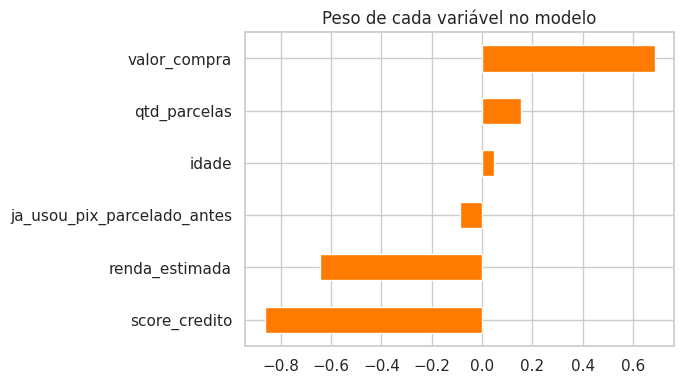

In [6]:
coef = pd.Series(modelo.coef_[0], index=features).sort_values()

fig, ax = plt.subplots(figsize=(7,4))
coef.plot(kind="barh", color="#FF7A00", ax=ax)
ax.set_title("Peso de cada variável no modelo")
plt.tight_layout()
plt.savefig("../images/coeficientes_modelo.png", dpi=120)
plt.show()


## O que eu tirei desse estudo (juntando os 3 notebooks)

- Quanto mais parcelado, maior a inadimplência — o número de parcelas parece um
  bom sinal de risco
- Cliente que já usou o Pix parcelado antes atrasa menos, e isso não é só
  coincidência (qui-quadrado confirmou)
- Score de crédito separa bem quem paga de quem atrasa (visualmente e no teste t)
- No teste A/B, o lembrete de cobrança com opção de renegociar parece recuperar
  mais cliente do que o lembrete simples
- O modelo de regressão logística consegue captar esse padrão (AUC acima de 0.5,
  ou seja, melhor que chute aleatório), e as variáveis que mais pesaram fazem
  sentido com o que já tinha visto nos gráficos

Se fosse levar isso pra um cenário real, o próximo passo seria testar limites de
parcelamento por faixa de score/renda, rodar o teste A/B com mais tempo antes de
migrar todo mundo pro lembrete novo, e acompanhar esses números por safra ao
longo do tempo pra ver se o padrão se mantém.
